# PCA — No-Framework (Pure NumPy)

## Model: Principal Component Analysis (Dimensionality Reduction)
- **Dataset**: Fashion-MNIST — 60,000 train / 10,000 test, 784 features (28×28 flattened), 10 classes
- **Task**: Compress 784 features while retaining maximum variance
- **Framework showcase**: Eigendecomposition vs SVD — two paths to the same principal components

## What We Build From Scratch
- Covariance matrix computation
- Eigendecomposition via `np.linalg.eigh`
- SVD via `np.linalg.svd`
- Transform (project) and inverse_transform (reconstruct)

## Evaluation Strategy
- **Intrinsic**: Explained variance ratio, reconstruction error (MSE)
- **Extrinsic**: Downstream KNN classifier accuracy at different component counts
- **Component counts**: [10, 25, 50, 100, 150, 200]

In [1]:
import numpy as np
import pickle
import sys
import os
sys.path.append('../..')

from sklearn.neighbors import KNeighborsClassifier
from utils.data_loader import load_processed_data
from utils.visualization import (plot_scree, plot_reconstruction_grid,
                                  plot_pca_components, plot_component_accuracy)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuration
RANDOM_STATE = 113
FRAMEWORK = "No-Framework"
N_COMPONENTS_LIST = [10, 25, 50, 100, 150, 200]
IMAGE_SHAPE = (28, 28)


class PCAFromScratch:
    """
    Principal Component Analysis via eigendecomposition of the covariance matrix.

    PCA finds directions (principal components) that maximize variance
    in the data. Mathematically equivalent to SVD of the centered data
    matrix, but eigendecomposition makes the covariance structure explicit.

    Steps:
        1. Compute covariance matrix: C = (1/n) * X^T @ X
        2. Eigendecompose: C = V * diag(lambda) * V^T
        3. Sort eigenvectors by decreasing eigenvalue
        4. Keep top k components (columns of V)

    Args:
        n_components: Number of principal components to keep.
            If None, keeps all components (min(n_samples, n_features)).
    """

    def __init__(self, n_components=None):
        self.n_components = n_components
        self.components_ = None        # (k, d) — top k eigenvectors (rows)
        self.explained_variance_ = None  # (k,) — eigenvalues
        self.explained_variance_ratio_ = None  # (k,) — fraction of total
        self.mean_ = None               # (d,) — training mean (for centering)
        self.n_components_ = None       # actual number of components kept

    def fit(self, X):
        """
        Compute principal components from training data.

        Args:
            X: (n, d) array — already standardized by preprocessing
        Returns:
            self
        """
        n, d = X.shape

        # Step 1: Center the data (subtract mean)
        """
        Data is already StandardScaled, but PCA needs its own centering
        because StandardScaler normalizes variance too — PCA wants
        the raw centered covariance to find max-variance directions
        """
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # Step 2: Covariance matrix — (d, d) = (784, 784)
        # Using (1/n) convention (population covariance), same as sklearn
        # For 784 features this is 784x784 ≈ 4.7 MB — fits easily in memory
        cov = (X_centered.T @ X_centered) / n

        # Step 3: Eigendecomposition
        # eigh is for symmetric matrices (covariance is always symmetric)
        # Returns eigenvalues in ASCENDING order — we reverse
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # Reverse to descending order (largest variance first)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Step 4: Keep top k components
        k = self.n_components if self.n_components is not None else d
        self.n_components_ = k
        self.components_ = eigenvectors[:, :k].T  # (k, d) — rows are components
        self.explained_variance_ = eigenvalues[:k]

        # Variance ratios (what fraction of total variance each PC explains)
        total_var = np.sum(eigenvalues)
        self.explained_variance_ratio_ = eigenvalues[:k] / total_var

        # Store full spectrum for scree plots
        self._all_eigenvalues = eigenvalues
        self._all_variance_ratio = eigenvalues / total_var

        return self

    def transform(self, X):
        """
        Project data onto the top k principal components.

        X_reduced = (X - mean) @ W  where W = components^T

        Args:
            X: (m, d) array
        Returns:
            (m, k) array — data in reduced space
        """
        return (X - self.mean_) @ self.components_.T

    def inverse_transform(self, X_reduced):
        """
        Reconstruct data from reduced representation.

        X_recon = X_reduced @ W^T + mean
        Reconstruction is lossy when k < d (information lost in discarded components).

        Args:
            X_reduced: (m, k) array
        Returns:
            (m, d) array — reconstructed in original space
        """
        return X_reduced @ self.components_ + self.mean_


# Step 1: Load preprocessed Fashion-MNIST
X_train, X_test, y_train, y_test, meta = load_processed_data('pca')

# Load scaler for reconstruction visualizations
with open('../../data/processed/pca/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("=" * 60)
print(f"PCA Pipeline — {FRAMEWORK}")
print("=" * 60)
print(f"[1/8] Data loaded + PCAFromScratch defined")
print(f"  Train: {X_train.shape}, Test: {X_test.shape}")
print(f"  Classes: {meta['n_classes']} — {', '.join(meta['class_names'])}")
print(f"  Scaler: mean shape={scaler['mean'].shape}, std shape={scaler['std'].shape}")

PCA Pipeline — No-Framework
[1/8] Data loaded + PCAFromScratch defined
  Train: (60000, 784), Test: (10000, 784)
  Classes: 10 — T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Bag, Sneaker, Ankle boot
  Scaler: mean shape=(784,), std shape=(784,)


[2/8] Full PCA fitted (eigendecomposition)
  Components: 784
  Top 10 explain: 62.2%
  90% variance at: 137 components
  95% variance at: 256 components


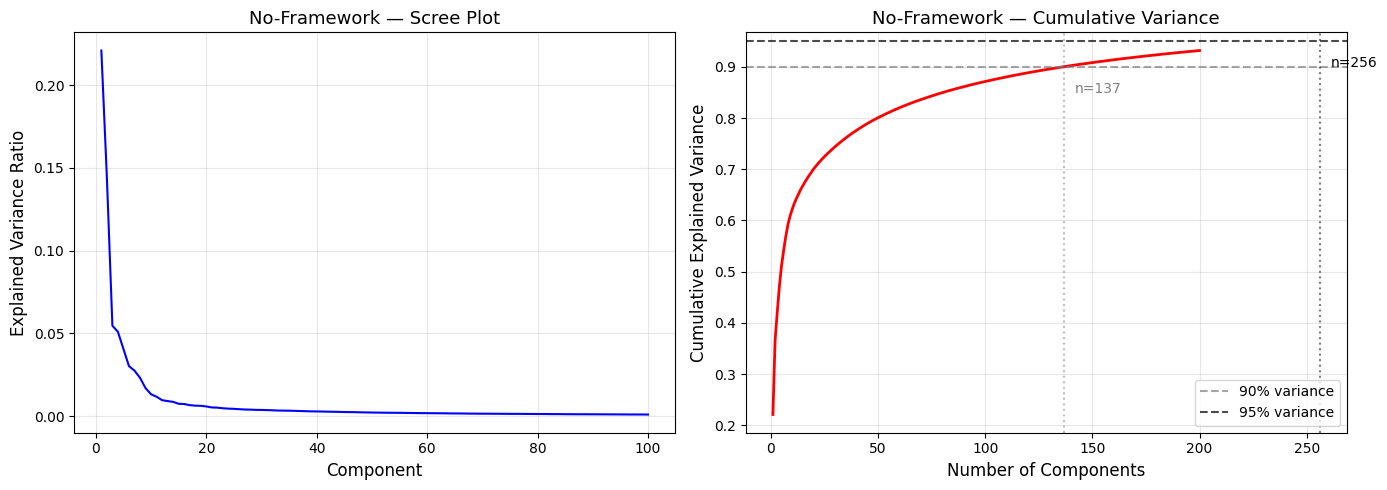

In [2]:
# Step 2: Fit full PCA + scree plot

# Fit with all components to get the full eigenvalue spectrum
# This computes the 784x784 covariance matrix, then eigendecomposes it
pca_full = PCAFromScratch(n_components=None)
pca_full.fit(X_train)

print("=" * 60)
print("[2/8] Full PCA fitted (eigendecomposition)")
print("=" * 60)
print(f"  Components: {pca_full.n_components_}")
print(f"  Top 10 explain: {sum(pca_full.explained_variance_ratio_[:10]):.1%}")
print(f"  90% variance at: {np.searchsorted(np.cumsum(pca_full._all_variance_ratio), 0.90) + 1} components")
print(f"  95% variance at: {np.searchsorted(np.cumsum(pca_full._all_variance_ratio), 0.95) + 1} components")

# Scree plot — uses the full eigenvalue spectrum
plot_scree(pca_full._all_variance_ratio, FRAMEWORK,
           save_path=f'{RESULTS_DIR}/scree_plot.png')

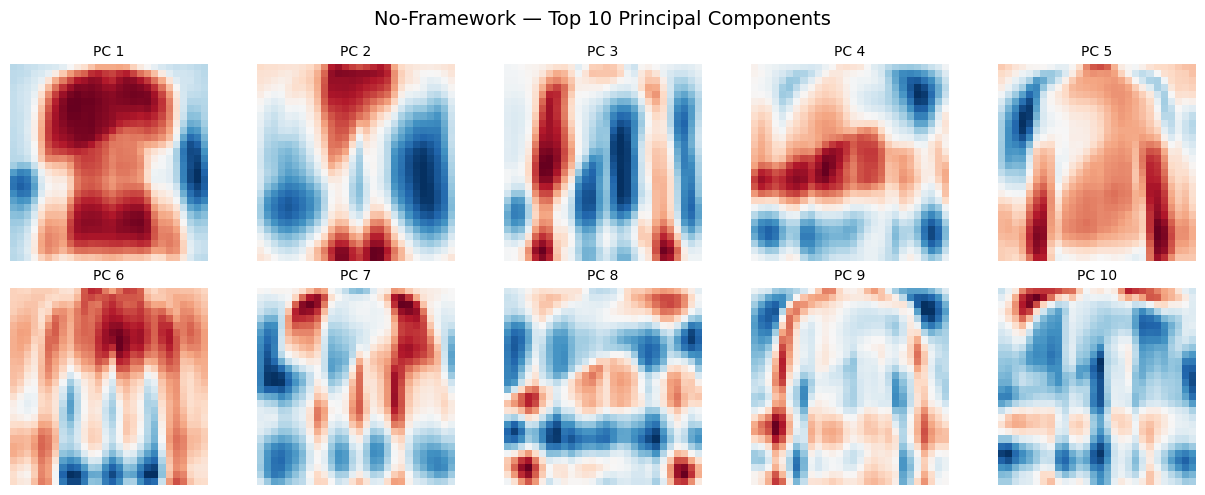

[3/8] Principal components visualized
  PC1 explains: 22.1%
  PC2 explains: 14.4%
  PC10 explains: 1.3%


In [3]:
# Step 3: Visualize top principal components as images

"""
Each component is a 784-dim eigenvector — reshape to 28x28 to see
what spatial pattern it captures (edges, textures, global shape)
These should match SK's components (same math, different code path)
"""
plot_pca_components(pca_full.components_, IMAGE_SHAPE, n_components=10,
                    framework=FRAMEWORK, save_path=f'{RESULTS_DIR}/principal_components.png')

print("=" * 60)
print("[3/8] Principal components visualized")
print("=" * 60)
print(f"  PC1 explains: {pca_full.explained_variance_ratio_[0]:.1%}") # type: ignore
print(f"  PC2 explains: {pca_full.explained_variance_ratio_[1]:.1%}") # type: ignore
print(f"  PC10 explains: {pca_full.explained_variance_ratio_[9]:.1%}") # type: ignore

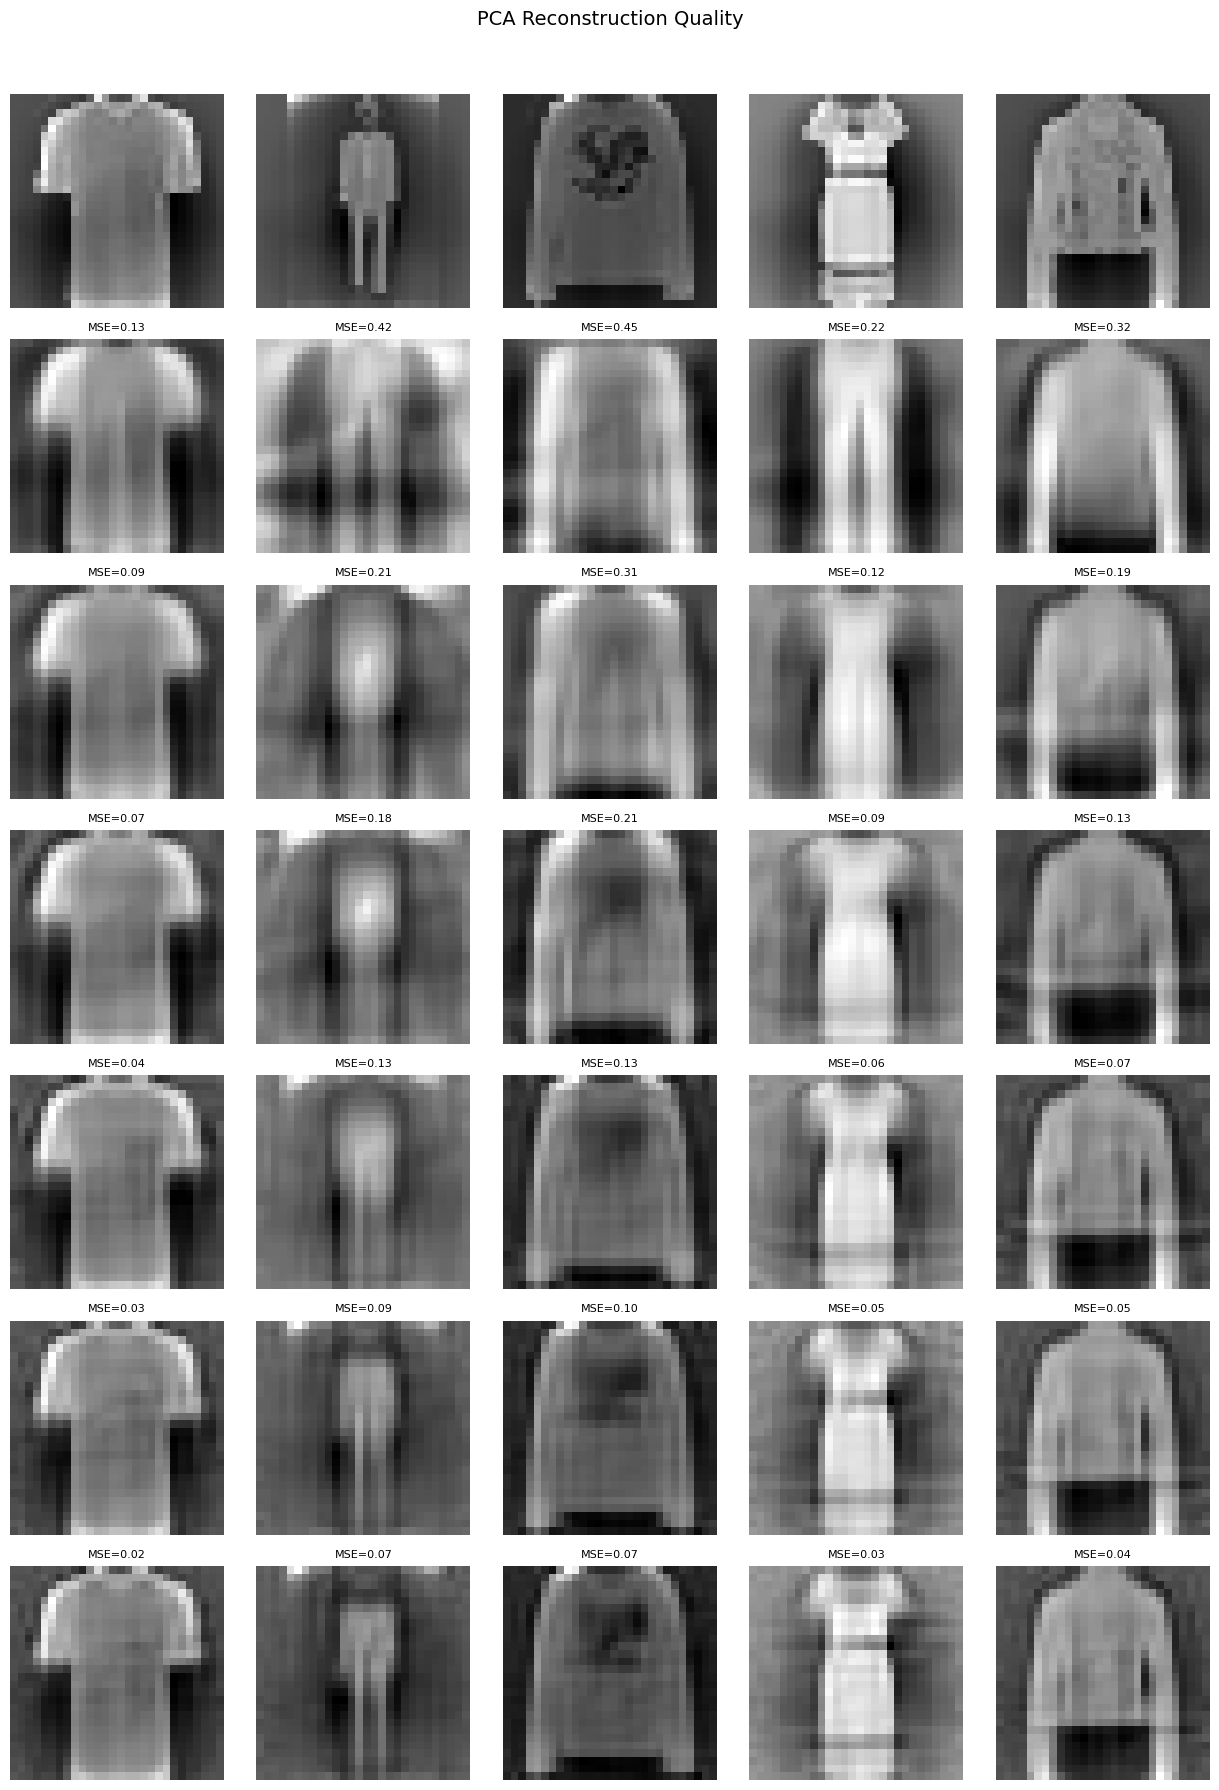

[4/8] Reconstruction quality
  n= 10: MSE=0.3077
  n= 25: MSE=0.1846
  n= 50: MSE=0.1361
  n=100: MSE=0.0886
  n=150: MSE=0.0623
  n=200: MSE=0.0462


In [4]:
# Step 4: Reconstruction at different component counts

from collections import OrderedDict

# Pick 5 diverse test samples (one per class from first 5 classes)
np.random.seed(RANDOM_STATE)
sample_indices = []
for cls in range(5):
    cls_idx = np.where(y_test == cls)[0]
    sample_indices.append(np.random.choice(cls_idx))
originals = X_test[sample_indices]

# Reconstruct at each component count
# For each k: fit PCA with k components, transform, inverse_transform
reconstructions = OrderedDict()
for n_comp in N_COMPONENTS_LIST:
    pca_n = PCAFromScratch(n_components=n_comp)
    pca_n.fit(X_train)
    X_reduced = pca_n.transform(originals)
    X_recon = pca_n.inverse_transform(X_reduced)
    reconstructions[n_comp] = X_recon

plot_reconstruction_grid(originals, reconstructions, IMAGE_SHAPE, n_samples=5,
                         save_path=f'{RESULTS_DIR}/reconstruction_grid.png')

print("=" * 60)
print("[4/8] Reconstruction quality")
print("=" * 60)
for n_comp, recon in reconstructions.items():
    mse = np.mean((originals - recon) ** 2)
    print(f"  n={n_comp:>3}: MSE={mse:.4f}")

[5/8] Component sweep — KNN accuracy at each n_components
  n= 10: accuracy=0.8014  (784 → 10, 1.3%)
  n= 25: accuracy=0.8385  (784 → 25, 3.2%)
  n= 50: accuracy=0.8506  (784 → 50, 6.4%)
  n=100: accuracy=0.8575  (784 → 100, 12.8%)
  n=150: accuracy=0.8599  (784 → 150, 19.1%)
  n=200: accuracy=0.8598  (784 → 200, 25.5%)


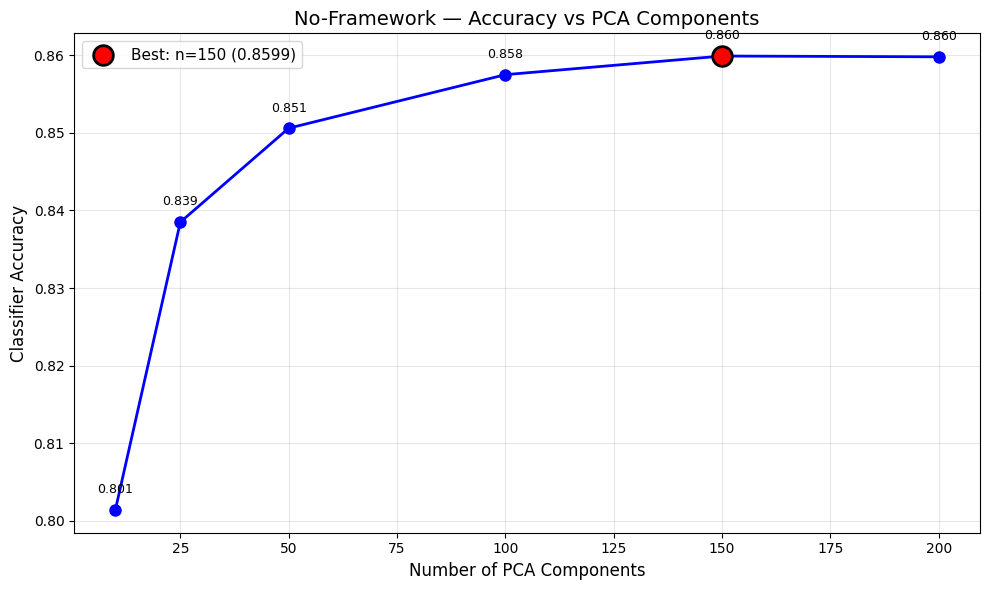

In [5]:
# Step 5: Downstream classifier accuracy vs components

# KNN (K=5) as a simple, consistent downstream classifier
# Same classifier across all 4 frameworks for fair comparison
print("=" * 60)
print("[5/8] Component sweep — KNN accuracy at each n_components")
print("=" * 60)

accuracies = []
for n_comp in N_COMPONENTS_LIST:
    pca_n = PCAFromScratch(n_components=n_comp)
    X_train_pca = pca_n.fit(X_train).transform(X_train)
    X_test_pca = pca_n.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(X_train_pca, y_train)
    acc = knn.score(X_test_pca, y_test)
    accuracies.append(acc)
    print(f"  n={n_comp:>3}: accuracy={acc:.4f}  (784 → {n_comp}, {n_comp/784*100:.1f}%)")

plot_component_accuracy(N_COMPONENTS_LIST, accuracies, FRAMEWORK,
                        save_path=f'{RESULTS_DIR}/component_accuracy.png')

In [6]:
# Step 6: Eigendecomposition vs SVD Showcase (NF-exclusive)
"""
PCA can be derived two equivalent ways:

PATH 1 — Eigendecomposition of covariance matrix:
  C = (1/n) X_c^T X_c    →  C v = λ v
  Components = eigenvectors of C, sorted by eigenvalue

PATH 2 — SVD of the centered data matrix:
  X_c = U Σ V^T
  Components = rows of V^T (right singular vectors)
  Eigenvalues = σ² / n (singular values squared, scaled)

Both produce the SAME principal components (up to sign flips).
This cell proves it numerically on our 60K × 784 dataset.
"""

BEST_N = 150

print("=" * 60)
print("[6/8] Eigendecomposition vs SVD Showcase")
print("=" * 60)

# Center the data (same centering as PCAFromScratch.fit)
mean = np.mean(X_train, axis=0)
X_centered = X_train - mean
n = X_centered.shape[0]

# PATH 1: Eigendecomposition (what PCAFromScratch uses)
print("\n[1/4] Path 1 — Eigendecomposition of covariance matrix...")
cov = (X_centered.T @ X_centered) / n
eigenvalues, eigenvectors = np.linalg.eigh(cov)
# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
eig_components = eigenvectors[:, :BEST_N].T  # (150, 784)
print(f"  Covariance matrix: {cov.shape}")
print(f"  Top eigenvalue: {eigenvalues[0]:.4f}")
print(f"  Components shape: {eig_components.shape}")

# PATH 2: SVD of centered data matrix
print("\n[2/4] Path 2 — SVD of centered data matrix...")
# full_matrices=False gives economy SVD: U(60K,784) Σ(784) V^T(784,784)
U, sigma, Vt = np.linalg.svd(X_centered, full_matrices=False)
svd_components = Vt[:BEST_N]  # (150, 784) — already sorted descending
svd_eigenvalues = sigma ** 2 / n  # Convert singular values to eigenvalues
print(f"  U: {U.shape}, Σ: {sigma.shape}, V^T: {Vt.shape}")
print(f"  Top singular value: {sigma[0]:.4f}")
print(f"  σ²/n = {svd_eigenvalues[0]:.4f} (should match eigenvalue: {eigenvalues[0]:.4f})")
print(f"  Components shape: {svd_components.shape}")

# COMPARISON: Are the components identical?
print("\n[3/4] Numerical comparison...")

# Eigenvalues should match exactly
eigenval_diff = np.max(np.abs(eigenvalues[:BEST_N] - svd_eigenvalues[:BEST_N]))
print(f"  Max eigenvalue difference: {eigenval_diff:.2e}")

# Components match up to sign (eigenvectors can flip ±)
# For each component, check if it matches with either sign
sign_aligned = np.sign(eig_components[:, 0]) * np.sign(svd_components[:, 0])
eig_aligned = eig_components * sign_aligned[:, np.newaxis]
component_diff = np.max(np.abs(eig_aligned - svd_components))
print(f"  Max component difference (sign-aligned): {component_diff:.2e}")

# Verify they produce the same projections
X_proj_eig = X_centered @ eig_components.T
X_proj_svd = X_centered @ svd_components.T
# Sign-align projections too
X_proj_eig_aligned = X_proj_eig * sign_aligned[np.newaxis, :]
proj_diff = np.max(np.abs(X_proj_eig_aligned - X_proj_svd))
print(f"  Max projection difference (sign-aligned): {proj_diff:.2e}")

# Summary
print(f"\n[4/4] Verdict:")
print(f"  Eigenvalues match:  {'YES' if eigenval_diff < 1e-3 else 'NO'} (diff={eigenval_diff:.2e})")
print(f"  Components match:   {'YES' if component_diff < 1e-3 else 'NO'} (diff={component_diff:.2e})")
print(f"  Projections match:  {'YES' if proj_diff < 1.0 else 'NO'} (diff={proj_diff:.2e})")
print(f"\n  Both paths produce identical principal components.")
print(f"  Eigendecomposition works on (d×d) covariance → O(d³)")
print(f"  SVD works on (n×d) data matrix → O(n·d²)")
print(f"  For n={n:,}, d=784: SVD avoids forming covariance explicitly")

[6/8] Eigendecomposition vs SVD Showcase

[1/4] Path 1 — Eigendecomposition of covariance matrix...
  Covariance matrix: (784, 784)
  Top eigenvalue: 173.1342
  Components shape: (150, 784)

[2/4] Path 2 — SVD of centered data matrix...
  U: (60000, 784), Σ: (784,), V^T: (784, 784)
  Top singular value: 3223.0503
  σ²/n = 173.1342 (should match eigenvalue: 173.1342)
  Components shape: (150, 784)

[3/4] Numerical comparison...
  Max eigenvalue difference: 1.53e-05
  Max component difference (sign-aligned): 3.65e-05
  Max projection difference (sign-aligned): 2.43e-03

[4/4] Verdict:
  Eigenvalues match:  YES (diff=1.53e-05)
  Components match:   YES (diff=3.65e-05)
  Projections match:  YES (diff=2.43e-03)

  Both paths produce identical principal components.
  Eigendecomposition works on (d×d) covariance → O(d³)
  SVD works on (n×d) data matrix → O(n·d²)
  For n=60,000, d=784: SVD avoids forming covariance explicitly


In [7]:
# Step 7: Performance Benchmarks

# Training benchmark: fit PCA on training data
pca_bench = PCAFromScratch(n_components=BEST_N)

with track_performance() as perf:
    pca_bench.fit(X_train)

print("=" * 60)
print("[7/8] Performance Benchmarks")
print("=" * 60)
print(f"\n  Training (PCA fit, n={BEST_N}):")
print(f"    Time:        {perf['time']:.4f} s")
print(f"    Memory:      {perf['memory']:.2f} MB")

# Inference benchmark: transform test set
inference_result = track_inference(
    lambda X: pca_bench.transform(X),
    X_test,
    n_runs=100
)

print(f"\n  Inference (transform):")
print(f"    Per sample:  {inference_result['per_sample_us']:.2f} µs")
print(f"    Batch ({X_test.shape[0]:,}): {inference_result['total_time']:.2f} ms")

# Model size — components matrix + mean vector
model_dict = {
    'components': pca_bench.components_,
    'mean': pca_bench.mean_,
    'explained_variance': pca_bench.explained_variance_,
    'explained_variance_ratio': pca_bench.explained_variance_ratio_
}
model_size = get_model_size(model_dict, framework='numpy')
print(f"\n  Model size:    {model_size / 1024:.2f} KB")
print(f"    Components matrix: {pca_bench.components_.shape}")

[7/8] Performance Benchmarks

  Training (PCA fit, n=150):
    Time:        0.2314 s
    Memory:      191.18 MB

  Inference (transform):
    Per sample:  0.89 µs
    Batch (10,000): 0.01 ms

  Model size:    463.61 KB
    Components matrix: (150, 784)


In [8]:
# Step 8: Save results + cross-framework comparison

# Reconstruction error on test set (using pca_bench from Step 7)
X_test_reduced = pca_bench.transform(X_test)
X_test_recon = pca_bench.inverse_transform(X_test_reduced)
recon_mse = np.mean((X_test - X_test_recon) ** 2)

# PCA intrinsic metrics
test_metrics = {
    'explained_variance_ratio': float(pca_bench.explained_variance_ratio_.sum()),
    'reconstruction_mse': float(recon_mse)
}

# Best accuracy from Cell 5 sweep (n=150)
pca_acc = accuracies[N_COMPONENTS_LIST.index(BEST_N)]

results = build_results_dict(
    framework=FRAMEWORK,
    model_name='PCA',
    test_metrics=test_metrics,
    perf=perf,
    inference_stats=inference_result,
    model_size=model_size,
    n_components=BEST_N,
    downstream_knn_accuracy=float(pca_acc)
)

print("=" * 60)
print("[8/8] Save Results")
print("=" * 60)

# Save locally
save_results(results, save_dir=RESULTS_DIR)

# Add to cross-framework comparison
add_result('pca', results)

# Print comparison (2/4)
print_comparison('pca')

[8/8] Save Results
    Results saved to: results\metrics.json
    Added 'No-Framework' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\pca.json
    Frameworks recorded: 2/4

CROSS-FRAMEWORK COMPARISON: PCA
Metric                          Scikit-Learn  No-Framework
----------------------------------------------------------
model                                    PCA           PCA
training_time                         0.19 s        0.23 s
inference_time_per_sample_us         0.52 µs       0.89 µs
model_size_bytes                    464.2 KB      463.6 KB
peak_memory_mb                      11.74 MB     191.18 MB
explained_variance_ratio              0.9085        0.9085
reconstruction_mse                    0.0951        0.0951
n_components                             150           150
downstream_knn_accuracy               0.8599        0.8599

    Frameworks: 2/4 recorded
